MONTHLY SALES DATA

Total Sales:
 M01AB    10499.440
M01AE     8156.000
N02BA     8051.459
N02BE    62477.945
N05B     18348.300
N05C      1249.000
R03      11737.250
R06       6066.380
dtype: float64
Average Monthly Sales:
 M01AB    149.992000
M01AE    116.514286
N02BA    115.020843
N02BE    892.542071
N05B     262.118571
N05C      17.842857
R03      167.675000
R06       86.662571
dtype: float64


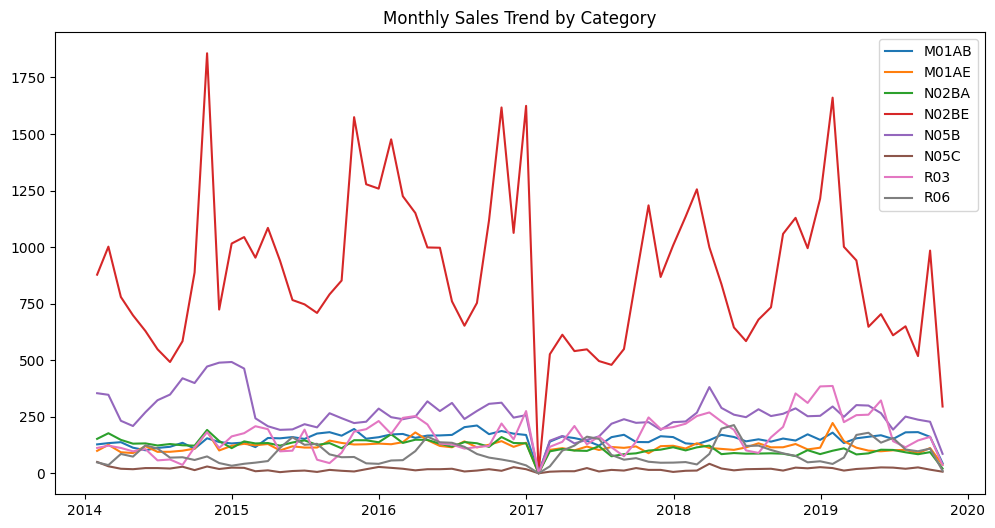

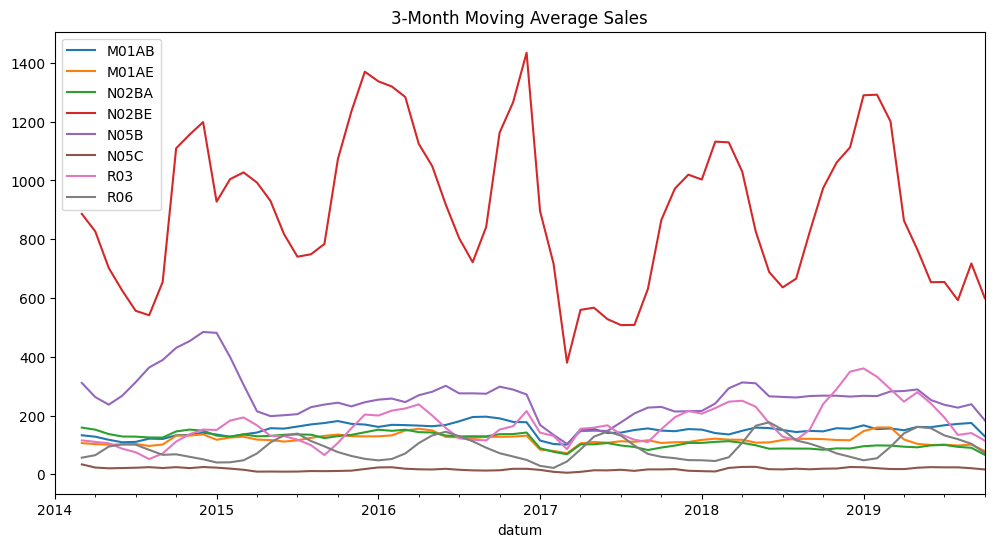

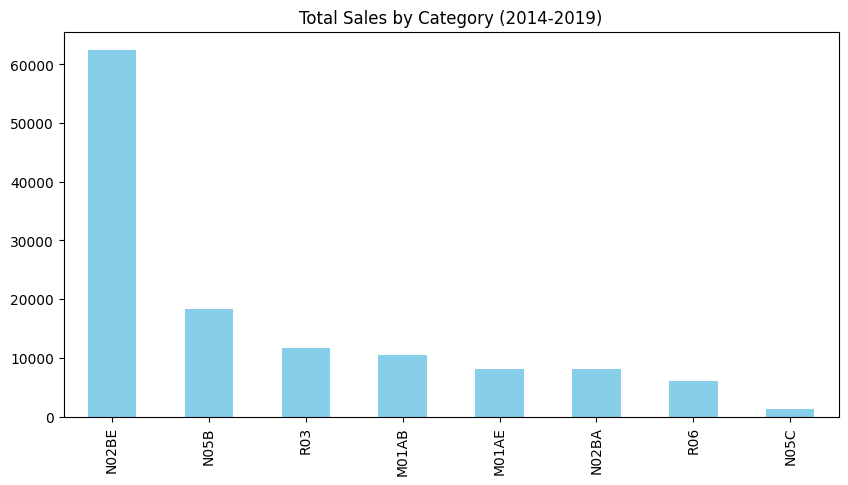

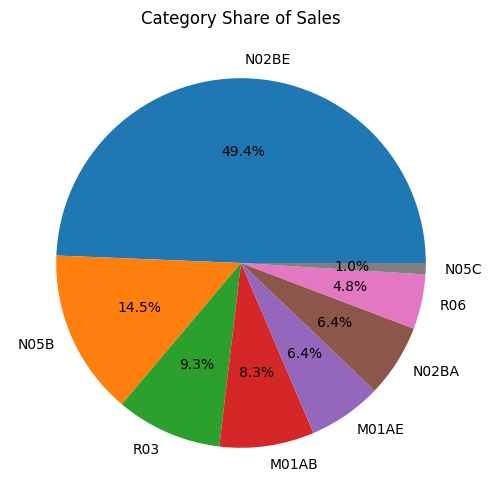

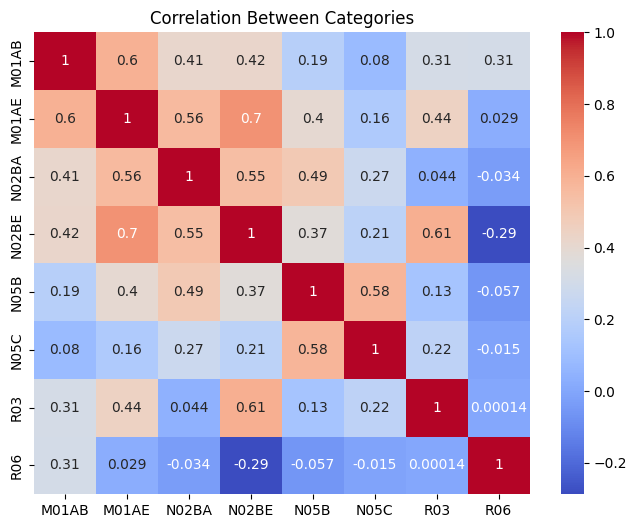

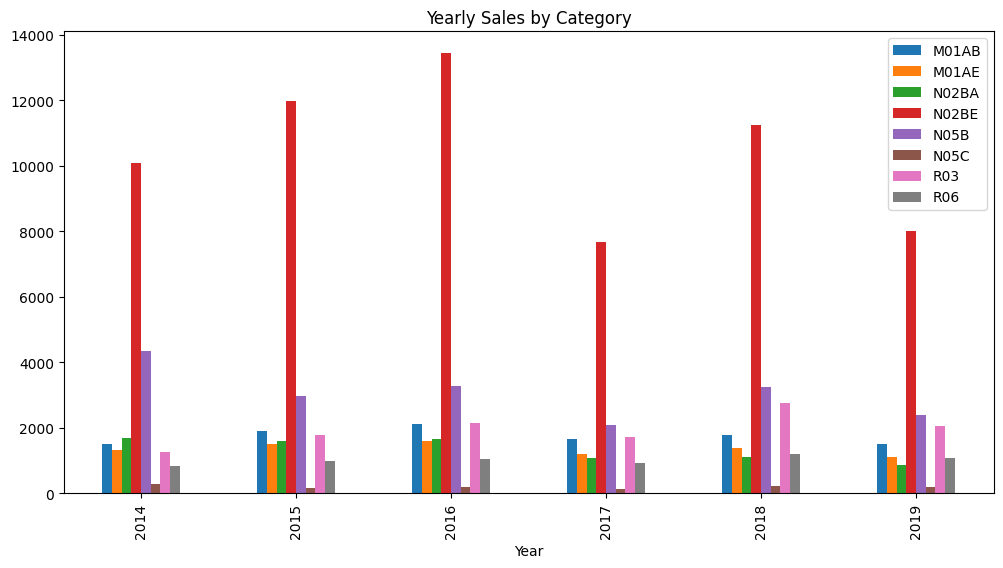

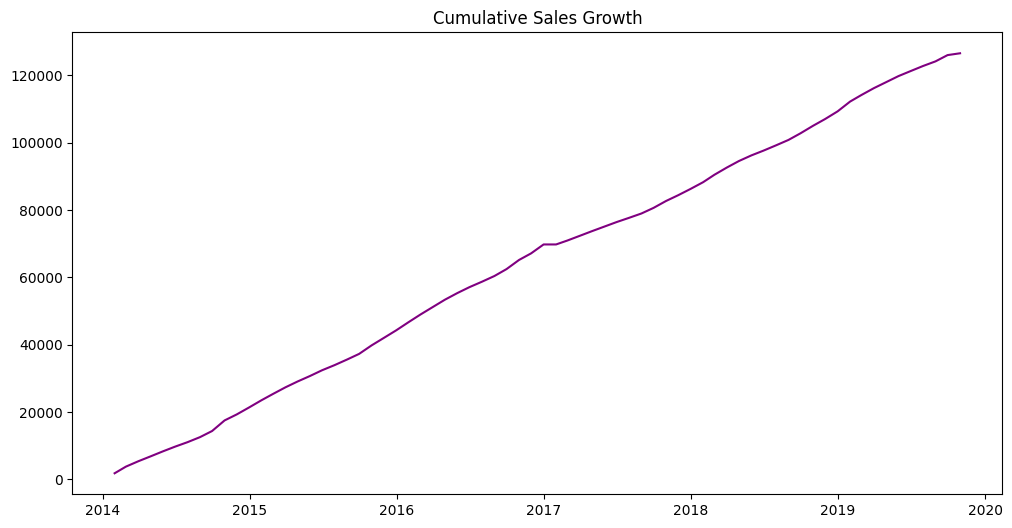

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_month = pd.read_csv("/content/salesmonthly.csv", encoding="latin1")
df_month['datum'] = pd.to_datetime(df_month['datum'])

# KPIs
totals = df_month.drop(columns=['datum']).sum()
averages = df_month.drop(columns=['datum']).mean()
print("Total Sales:\n", totals)
print("Average Monthly Sales:\n", averages)

# Monthly trend
plt.figure(figsize=(12,6))
for col in df_month.columns[1:]:
    plt.plot(df_month['datum'], df_month[col], label=col)
plt.legend()
plt.title("Monthly Sales Trend by Category")
plt.show()

# Moving average
df_ma = df_month.set_index('datum').rolling(3).mean()
df_ma.plot(figsize=(12,6))
plt.title("3-Month Moving Average Sales")
plt.show()

# Top categories
top_cats = totals.sort_values(ascending=False)
top_cats.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title("Total Sales by Category (2014-2019)")
plt.show()

# Category share
plt.figure(figsize=(6,6))
plt.pie(top_cats, labels=top_cats.index, autopct='%1.1f%%')
plt.title("Category Share of Sales")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_month.drop(columns=['datum']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Categories")
plt.show()

# Yearly breakdown
df_month['Year'] = df_month['datum'].dt.year
yearly = df_month.groupby('Year')[df_month.columns[1:9]].sum()
yearly.plot(kind='bar', figsize=(12,6))
plt.title("Yearly Sales by Category")
plt.show()

# Cumulative growth
df_month['Total'] = df_month.drop(columns=['datum','Year']).sum(axis=1)
df_month['Cumulative'] = df_month['Total'].cumsum()
plt.figure(figsize=(12,6))
plt.plot(df_month['datum'], df_month['Cumulative'], color='purple')
plt.title("Cumulative Sales Growth")
plt.show()


WEEKLY SALES DATA

Total Weekly Sales:
 M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64
Average Weekly Sales:
 M01AB     35.102441
M01AE     27.167611
N02BA     27.060295
N02BE    208.627161
N05B      61.740853
N05C       4.138935
R03       38.439811
R06       20.224561
dtype: float64


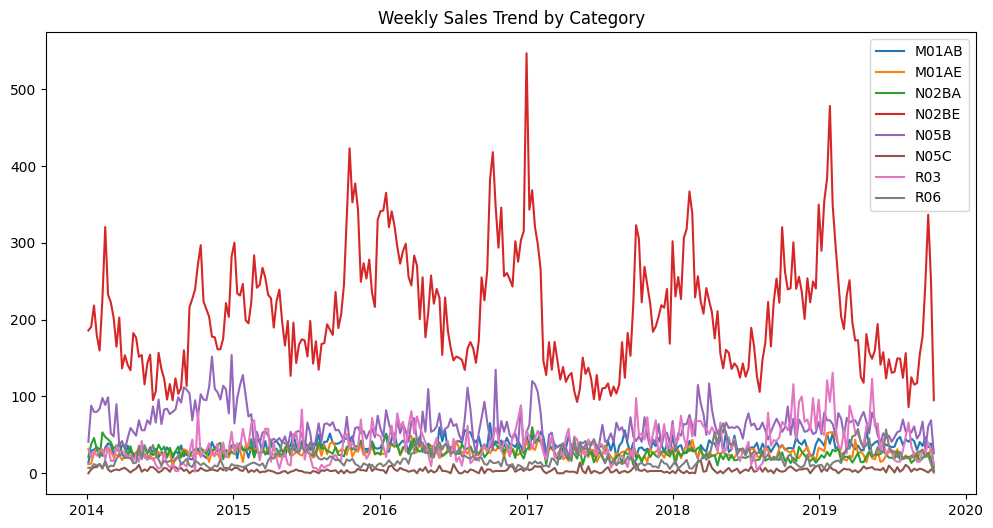

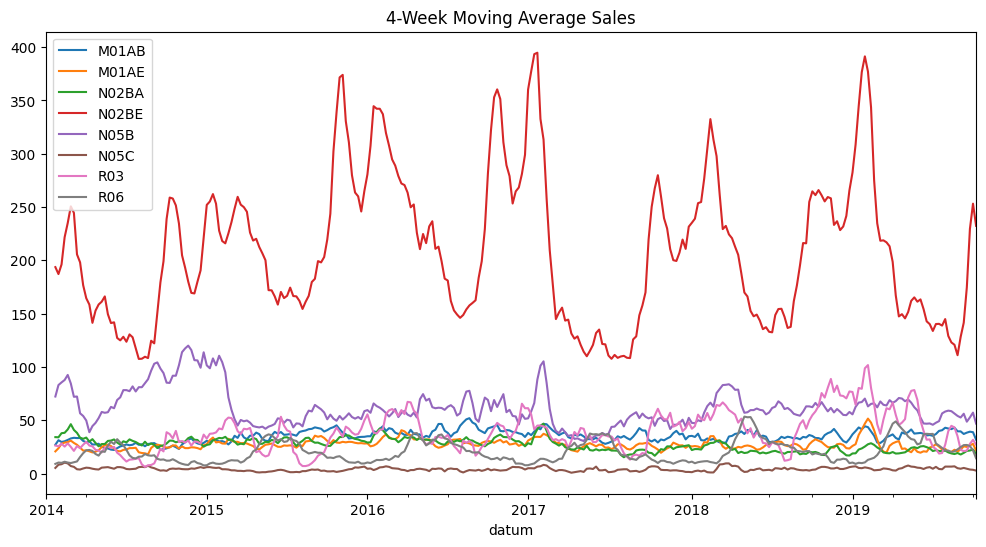

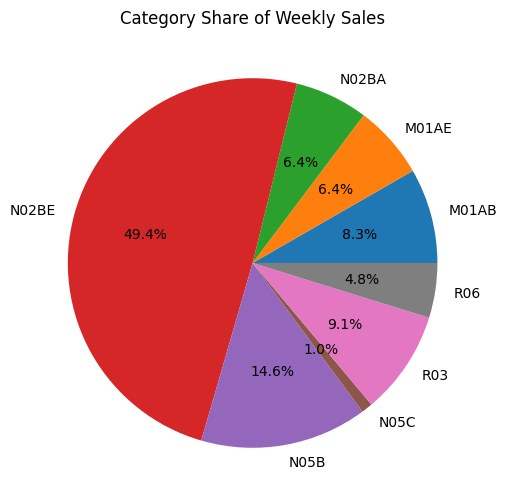

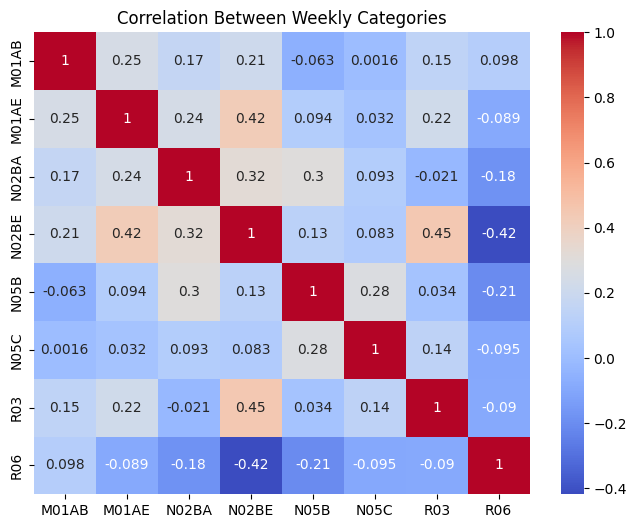

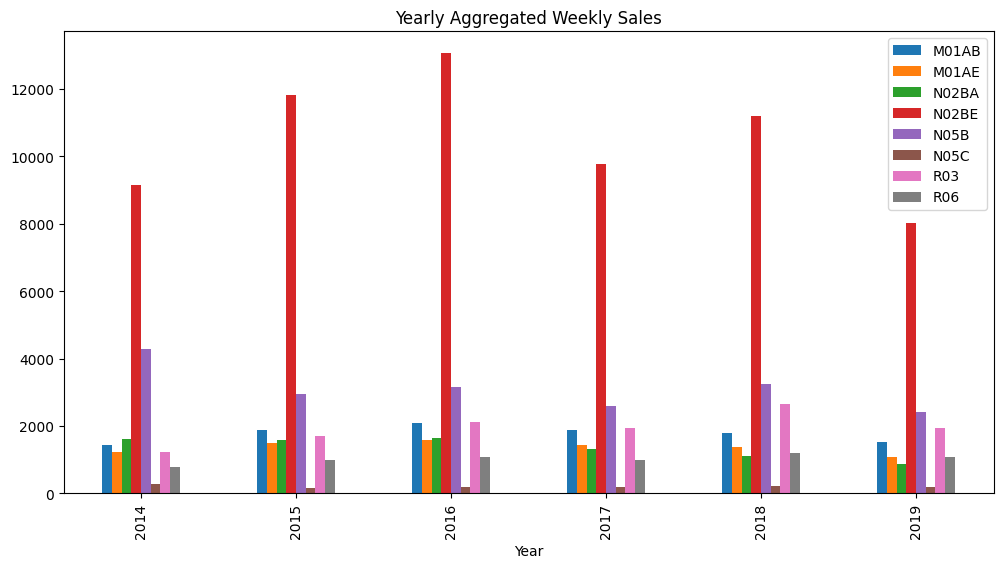

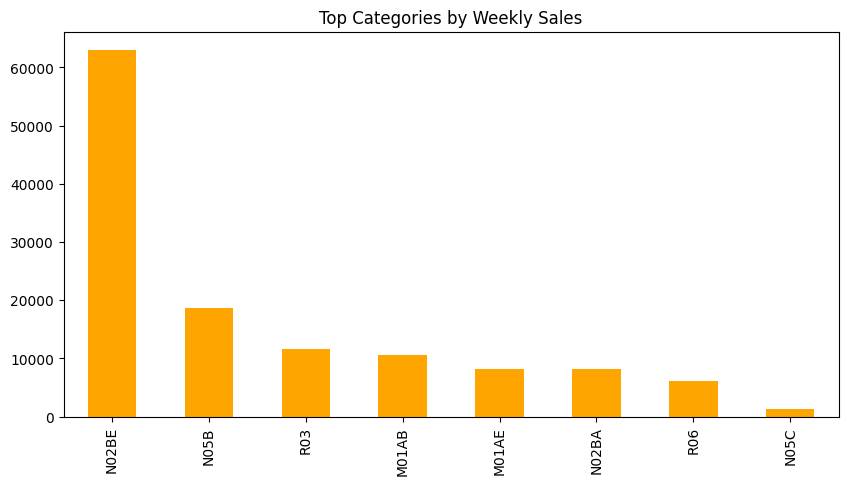

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_week = pd.read_csv("/content/salesweekly.csv", encoding="latin1")
df_week['datum'] = pd.to_datetime(df_week['datum'])

# KPIs
totals = df_week.drop(columns=['datum']).sum()
averages = df_week.drop(columns=['datum']).mean()
print("Total Weekly Sales:\n", totals)
print("Average Weekly Sales:\n", averages)

# Weekly trend
plt.figure(figsize=(12,6))
for col in df_week.columns[1:]:
    plt.plot(df_week['datum'], df_week[col], label=col)
plt.legend()
plt.title("Weekly Sales Trend by Category")
plt.show()

# Rolling average (4 weeks)
df_rolling = df_week.set_index('datum').rolling(4).mean()
df_rolling.plot(figsize=(12,6))
plt.title("4-Week Moving Average Sales")
plt.show()

# Category share
plt.figure(figsize=(6,6))
plt.pie(totals, labels=totals.index, autopct='%1.1f%%')
plt.title("Category Share of Weekly Sales")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_week.drop(columns=['datum']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Weekly Categories")
plt.show()

# Seasonal pattern by year
df_week['Year'] = df_week['datum'].dt.year
yearly = df_week.groupby('Year')[df_week.columns[1:9]].sum()
yearly.plot(kind='bar', figsize=(12,6))
plt.title("Yearly Aggregated Weekly Sales")
plt.show()

# Top categories
top_cats = totals.sort_values(ascending=False)
top_cats.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Top Categories by Weekly Sales")
plt.show()


DAILY SALES DATA

Total Daily Sales:
 M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64
Average Daily Sales:
 M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
N02BE    29.917095
N05B      8.853627
N05C      0.593522
R03       5.512262
R06       2.900198
dtype: float64


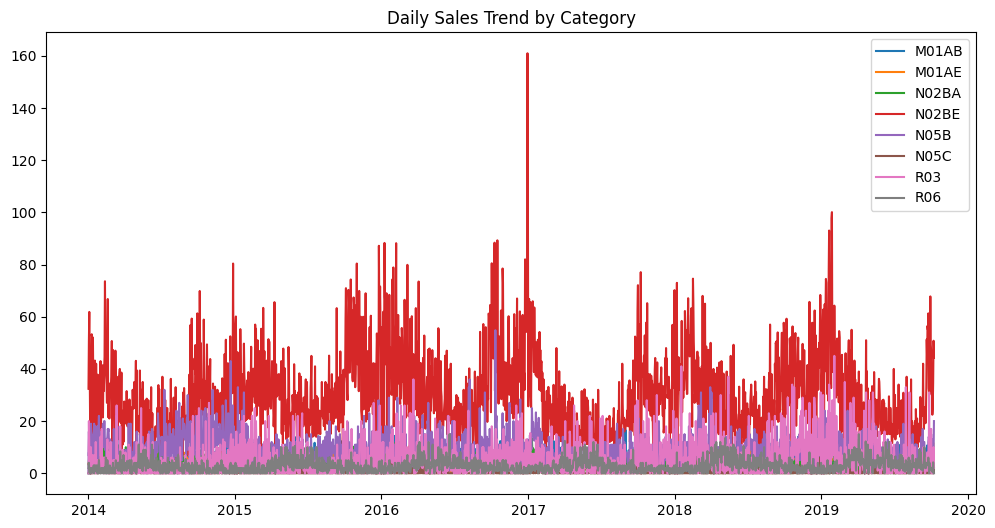

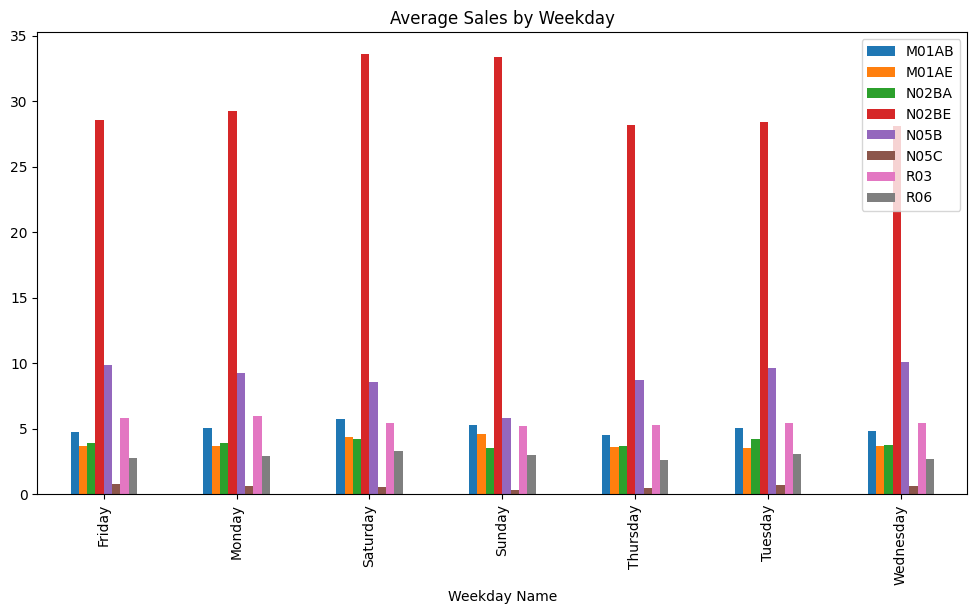

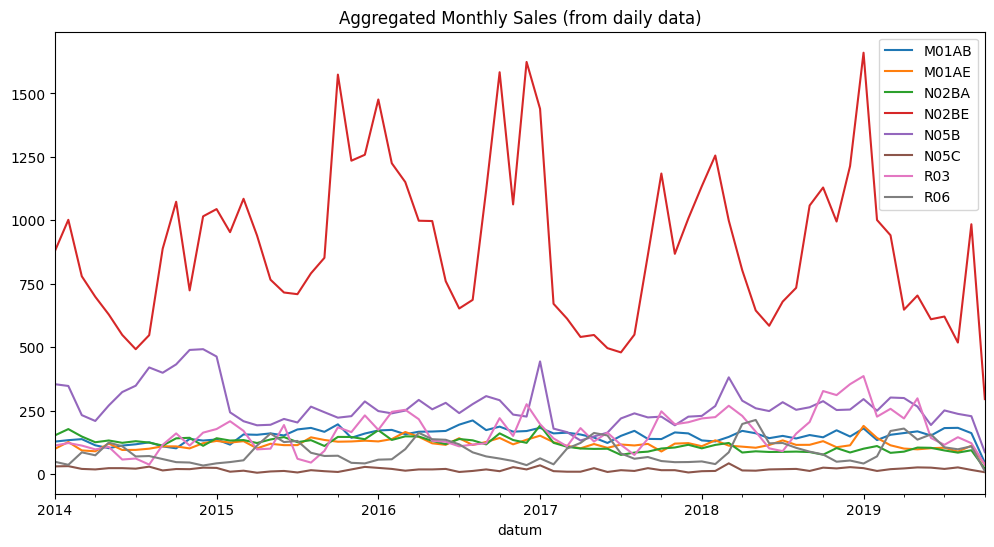

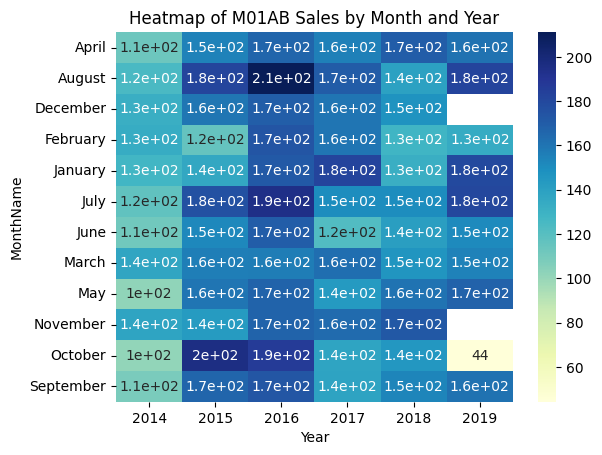

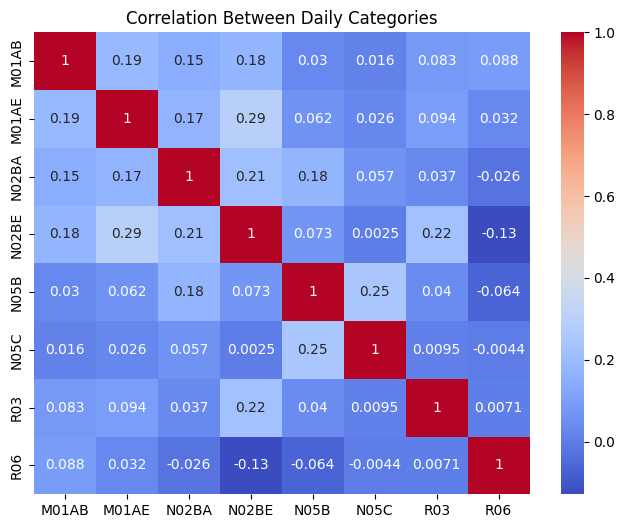

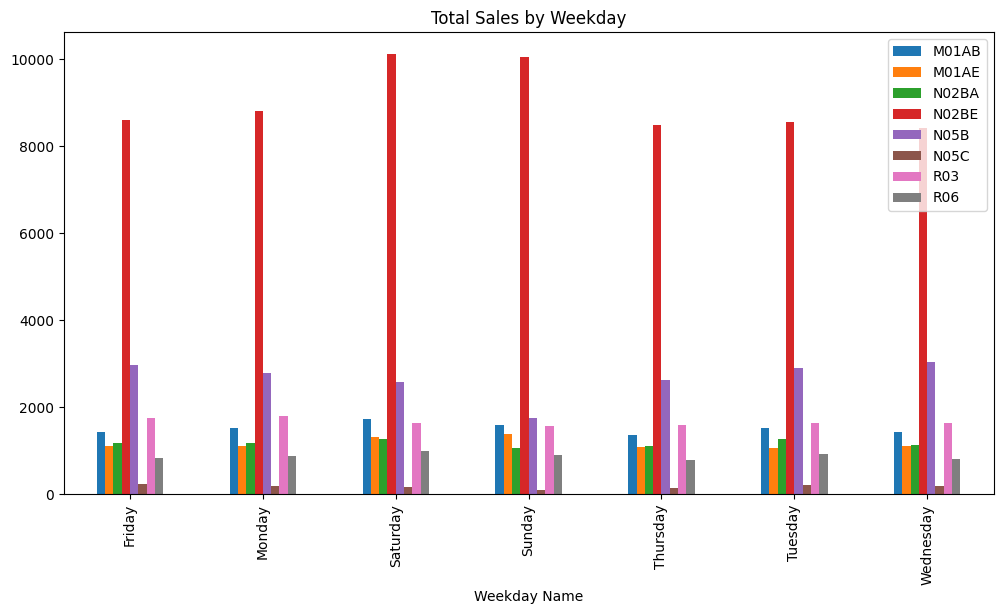

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_day = pd.read_csv("/content/salesdaily.csv", encoding="latin1")
df_day['datum'] = pd.to_datetime(df_day['datum'])

# KPIs
totals = df_day.iloc[:,1:9].sum()
averages = df_day.iloc[:,1:9].mean()
print("Total Daily Sales:\n", totals)
print("Average Daily Sales:\n", averages)

# Daily trend
plt.figure(figsize=(12,6))
for col in df_day.columns[1:9]:
    plt.plot(df_day['datum'], df_day[col], label=col)
plt.legend()
plt.title("Daily Sales Trend by Category")
plt.show()

# Average by weekday
weekday_avg = df_day.groupby('Weekday Name').mean().iloc[:,1:9]
weekday_avg.plot(kind='bar', figsize=(12,6))
plt.title("Average Sales by Weekday")
plt.show()

# Monthly aggregation
monthly_totals = df_day.groupby(df_day['datum'].dt.to_period("M"))[df_day.columns[1:9]].sum()
monthly_totals.plot(figsize=(12,6))
plt.title("Aggregated Monthly Sales (from daily data)")
plt.show()


# Heatmap (categories vs months)
df_day['MonthName'] = df_day['datum'].dt.month_name()
pivot = df_day.pivot_table(values='M01AB', index='MonthName', columns='Year', aggfunc='sum')
sns.heatmap(pivot, cmap="YlGnBu", annot=True)
plt.title("Heatmap of M01AB Sales by Month and Year")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_day.iloc[:,1:9].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Daily Categories")
plt.show()

# Seasonal weekday patterns
weekday_totals = df_day.groupby('Weekday Name')[df_day.columns[1:9]].sum()
weekday_totals.plot(kind='bar', figsize=(12,6))
plt.title("Total Sales by Weekday")
plt.show()
